In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import pandas as pd
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore

In [21]:
if not os.path.exists('./plots'):
    os.makedirs('./plots')

In [22]:
def prepare_sample(pd_data, column_name):
    '''
    get the parameter list and age list of both male subjects and female subjects
    '''
    param_male = np.array(pd_data[column_name][pd_data['sex']==1])
    print('number of male subjects:', len(param_male))
    age_male = np.array(pd_data['age'][pd_data['sex']==1])
    param_female = np.array(pd_data[column_name][pd_data['sex']==2])
    print('number of female subjects:', len(param_female))
    age_female = np.array(pd_data['age'][pd_data['sex']==2])

    sorted_indices_male = np.argsort(age_male)
    age_male = age_male[sorted_indices_male]
    param_male = param_male[sorted_indices_male]

    sorted_indices_female = np.argsort(age_female)
    age_female = age_female[sorted_indices_female]
    param_female = param_female[sorted_indices_female]

    return param_male, age_male, param_female, age_female

In [23]:
def lowess_fit(x_sample, y_sample, frac=0.75, n_bootstrap = 1000):
    # frac: Fraction of data used for smoothing
    y_smoothed = lowess(y_sample, x_sample, frac=frac)[:, 1]
    # Bootstrap resampling to estimate confidence intervals
    bootstrap_samples = np.zeros((n_bootstrap, len(x_sample)))
    for i in range(n_bootstrap):
        indices = np.random.choice(range(len(x_sample)), len(x_sample), replace=True)
        x_resample = x_sample[indices]
        y_resample = y_sample[indices]
        bootstrap_samples[i, :] = lowess(y_resample, x_resample, frac=frac, xvals=x_sample)

    # Calculate confidence intervals
    lower_bound = np.percentile(bootstrap_samples, 2.5, axis=0)
    upper_bound = np.percentile(bootstrap_samples, 97.5, axis=0)

    return y_smoothed, lower_bound, upper_bound

In [24]:
def filter_samples(y_sample, x_sample, threshold = 1.5):
    #print(len(x_sample))
    # filter outliers
    z_scores = np.abs(zscore(y_sample))
    filtered_indices = z_scores < threshold
    x_filtered = x_sample[filtered_indices]
    y_filtered = y_sample[filtered_indices]
    print('number of subjects after filtering:', len(x_filtered))
    return y_filtered, x_filtered

def crop_age_range_line(age, y_smooth, low_bound, up_bound, low_age = 60, up_age=80):
    age_crop = age[(age>=low_age) & (age<=up_age)]
    y_smooth_crop = y_smooth[(age>=low_age) & (age<=up_age)]
    low_bound_crop = low_bound[(age>=low_age) & (age<=up_age)]
    up_bound_crop = up_bound[(age>=low_age) & (age<=up_age)]
    return age_crop, y_smooth_crop, low_bound_crop, up_bound_crop

## AV Curves for CN healthy subjects vs CN subjects with AD

In [25]:
# load healthy params 
health_param_file = './data/chinese_vascular_volume.csv'
health_param_data = pd.read_csv(health_param_file)
health_param_data = health_param_data.dropna()
health_param_data

,av,COW,PCA,MCA,ACA,PSC1,PSC2,PSC3,PMC,SAC,...,AC1,AC2,PGC,POper,PT,DPC2,Porb,RA,age,sex
0,14696.875,2257.000,1245.875,6312.750,1833.250,0,0.000,1.000,0.000,0,...,168.000,33.500,45.500,22.000,0.125,0.000,117.375,2898.125,88,1
1,13453.500,1476.125,1204.000,5490.250,2004.625,0,34.000,0.000,0.000,0,...,108.750,128.000,23.125,74.125,14.750,0.000,67.000,2861.375,84,1
2,16491.125,2219.000,1886.375,7574.000,2219.250,0,26.000,31.125,22.125,0,...,131.625,247.125,125.750,224.375,50.500,0.000,210.125,3256.625,77,1
3,11271.875,1096.750,1373.500,5340.000,1301.875,0,7.375,6.750,17.875,0,...,76.875,134.500,16.125,181.000,18.000,0.125,53.750,2598.500,42,2
4,16967.625,2918.750,1516.000,6773.750,1888.250,0,9.625,3.250,22.375,0,...,61.625,256.000,82.000,174.125,24.750,0.000,69.250,3510.750,85,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881,12659.875,1344.750,1539.750,5517.375,2004.500,0,29.375,0.000,0.000,0,...,142.375,136.375,22.250,57.750,124.250,25.125,74.500,2199.250,43,1
882,16553.500,2016.750,1940.000,6692.375,2887.750,0,15.000,0.000,0.000,0,...,162.875,209.000,51.875,30.500,30.875,20.625,57.750,3245.625,68,1
883,13909.500,1415.375,1771.375,6059.250,2002.500,0,8.000,0.000,4.875,0,...,170.375,277.875,82.125,47.500,52.625,45.250,88.000,2825.125,53,2
884,15717.500,1598.375,2071.375,6633.375,2240.125,0,14.625,10.125,7.000,0,...,151.125,244.875,81.500,145.125,56.750,12.125,45.875,2930.125,49,1


In [26]:
unhealth_param_file = './data/AD_chinese_vascular_volume.csv'
unhealth_param_data = pd.read_csv(unhealth_param_file)
unhealth_param_data = unhealth_param_data.dropna()
unhealth_param_data

,av,COW,ACA,MCA,PCA,age,sex
0,6337.125,759.125,1585.375,1661.625,869.250,84.333333,2
1,7765.750,878.500,934.375,3991.750,355.875,80.000000,2
2,11950.000,985.750,1533.750,6297.375,807.500,72.666667,1
3,11644.625,907.125,1913.625,5727.625,1071.125,70.083333,2
4,10675.500,779.750,1518.625,5412.250,1273.125,60.000000,2
...,...,...,...,...,...,...,...
114,10325.750,1137.250,1643.000,5386.125,460.625,84.416667,2
115,10486.375,1107.500,2053.625,4762.500,679.375,55.833333,1
116,12339.750,1389.250,1448.375,5759.375,1465.625,71.083333,2
117,15547.375,1454.500,2219.750,7322.500,1646.250,67.583333,1


#### whole-brain AV Curves, healthy subjects vs subjects with AD

In [27]:
## whole-brain AV  
health_param_male, health_age_male, health_param_female, health_age_female = prepare_sample(health_param_data, column_name='av')
# Apply LOESS smoothing
frac = 0.75 # Fraction of data used for smoothing
y_smoothed_male_health, lower_bound_male_health, upper_bound_male_health = lowess_fit(health_age_male, health_param_male, frac)
y_smoothed_female_health, lower_bound_female_health, upper_bound_female_health = lowess_fit(health_age_female, health_param_female, frac)

number of male subjects: 424
number of female subjects: 462


In [28]:
unhealth_param_male, unhealth_age_male, unhealth_param_female, unhealth_age_female = prepare_sample(unhealth_param_data, column_name='av')

unhealth_param_male_filtered, unhealth_age_male_filtered = filter_samples(unhealth_param_male, unhealth_age_male, threshold=2.0)
unhealth_param_female_filtered, unhealth_age_female_filtered = filter_samples(unhealth_param_female, unhealth_age_female, threshold=2.0)

# Apply LOESS smoothing
frac = 0.85 # Fraction of data used for smoothing
y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = lowess_fit(unhealth_age_male_filtered, unhealth_param_male_filtered, frac, n_bootstrap=1000)
y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = lowess_fit(unhealth_age_female_filtered, unhealth_param_female_filtered, frac, n_bootstrap=1000)

unhealth_age_male_filtered, y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = crop_age_range_line(unhealth_age_male_filtered, y_smoothed_male_unhealth, 
                                                                                                                                 lower_bound_male_unhealth, upper_bound_male_unhealth)
unhealth_age_female_filtered, y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = crop_age_range_line(unhealth_age_female_filtered, y_smoothed_female_unhealth, 
                                                                                                                                 lower_bound_female_unhealth, upper_bound_female_unhealth)

number of male subjects: 45
number of female subjects: 74
number of subjects after filtering: 44
number of subjects after filtering: 73


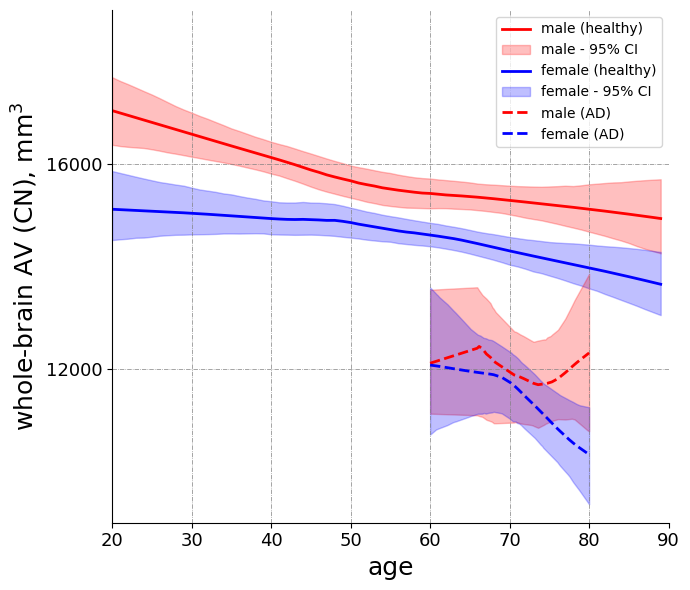

In [29]:
# Plot the the smoothed curve, and the confidence intervals
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Helvetica Neue']

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(health_age_male, y_smoothed_male_health, label='male (healthy)', color='red', linewidth=2)
ax.fill_between(health_age_male, lower_bound_male_health, upper_bound_male_health, color='red', alpha=0.25, label='male - 95% CI')
ax.plot(health_age_female, y_smoothed_female_health, label='female (healthy)', color='blue', linewidth=2)
ax.fill_between(health_age_female, lower_bound_female_health, upper_bound_female_health, color='blue', alpha=0.25, label='female - 95% CI')
ax.plot(unhealth_age_male_filtered, y_smoothed_male_unhealth, label='male (AD)', color='red', linewidth=2, linestyle='--', )
ax.fill_between(unhealth_age_male_filtered, lower_bound_male_unhealth, upper_bound_male_unhealth, color='red', alpha=0.25)
ax.plot(unhealth_age_female_filtered, y_smoothed_female_unhealth, label='female (AD) ', color='blue', linewidth=2, linestyle='--')
ax.fill_between(unhealth_age_female_filtered, lower_bound_female_unhealth, upper_bound_female_unhealth, color='blue', alpha=0.25)

ax.set_xlabel('age', fontsize=18)
ax.set_ylabel('whole-brain AV (CN), mm$^3$', fontsize=18)
ax.set_xlim((20,90))
ax.set_ylim((9000, 19000))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
plt.setp(ax.get_xticklabels(), fontsize=13)
plt.setp(ax.get_yticklabels(), fontsize=13)
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.savefig('./plots/CN_health_vs_AD_whole_AV.png', dpi=500, bbox_inches='tight')
plt.show()

####  AV Curves in 4 typical regions, healthy subjects vs subjects with AD

number of male subjects: 424
number of female subjects: 462
number of male subjects: 45
number of female subjects: 74
number of subjects after filtering: 43
number of subjects after filtering: 72
number of male subjects: 424
number of female subjects: 462
number of male subjects: 45
number of female subjects: 74
number of subjects after filtering: 43
number of subjects after filtering: 72
number of male subjects: 424
number of female subjects: 462
number of male subjects: 45
number of female subjects: 74
number of subjects after filtering: 43
number of subjects after filtering: 70
number of male subjects: 424
number of female subjects: 462
number of male subjects: 45
number of female subjects: 74
number of subjects after filtering: 43
number of subjects after filtering: 73


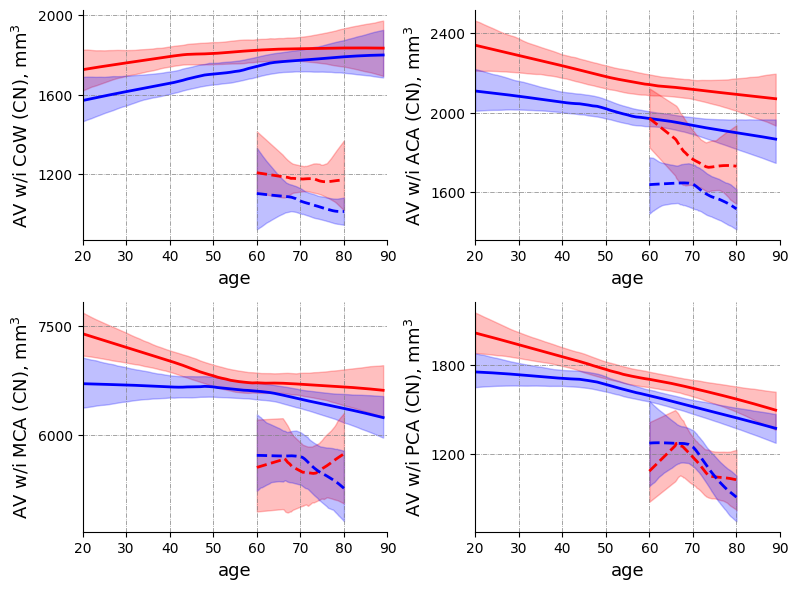

In [30]:
fig = plt.figure(figsize=(8, 6))
column_names = ['CoW', 'ACA', 'MCA', 'PCA']
for idx, column_name in enumerate(column_names):
    ax = fig.add_subplot(2, 2, idx+1)
    health_param_male, health_age_male, health_param_female, health_age_female = prepare_sample(health_param_data, column_name=column_name.upper())
    # Apply LOESS smoothing
    # Fraction of data used for smoothing
    y_smoothed_male_health, lower_bound_male_health, upper_bound_male_health = lowess_fit(health_age_male, health_param_male, frac = 0.75)
    y_smoothed_female_health, lower_bound_female_health, upper_bound_female_health = lowess_fit(health_age_female, health_param_female, frac = 0.75)
    ax.plot(health_age_male, y_smoothed_male_health, label='male (healthy)', color='red', linewidth=2)
    ax.fill_between(health_age_male, lower_bound_male_health, upper_bound_male_health, color='red', alpha=0.25, label='male - 95% CI')

    ax.plot(health_age_female, y_smoothed_female_health, label='female (healthy)', color='blue', linewidth=2)
    ax.fill_between(health_age_female, lower_bound_female_health, upper_bound_female_health, color='blue', alpha=0.25, label='female - 95% CI')



    unhealth_param_male, unhealth_age_male, unhealth_param_female, unhealth_age_female = prepare_sample(unhealth_param_data, column_name=column_name.upper())

    unhealth_param_male_filtered, unhealth_age_male_filtered = filter_samples(unhealth_param_male, unhealth_age_male, threshold=2.0)
    unhealth_param_female_filtered, unhealth_age_female_filtered = filter_samples(unhealth_param_female, unhealth_age_female, threshold=2.0)
    y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = lowess_fit(unhealth_age_male_filtered, unhealth_param_male_filtered, frac = 0.85)
    y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = lowess_fit(unhealth_age_female_filtered, unhealth_param_female_filtered, frac = 0.85)

    unhealth_age_male_filtered, y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = crop_age_range_line(unhealth_age_male_filtered, y_smoothed_male_unhealth, 
                                                                                                                                 lower_bound_male_unhealth, upper_bound_male_unhealth)
    unhealth_age_female_filtered, y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = crop_age_range_line(unhealth_age_female_filtered, y_smoothed_female_unhealth, 
                                                                                                                                 lower_bound_female_unhealth, upper_bound_female_unhealth)

    ax.plot(unhealth_age_male_filtered, y_smoothed_male_unhealth, label='male (AD)', color='red', linewidth=2, linestyle='--', )
    ax.fill_between(unhealth_age_male_filtered, lower_bound_male_unhealth, upper_bound_male_unhealth, color='red', alpha=0.25)

    ax.plot(unhealth_age_female_filtered, y_smoothed_female_unhealth, label='female (AD)', color='blue', linewidth=2, linestyle='--')
    ax.fill_between(unhealth_age_female_filtered, lower_bound_female_unhealth, upper_bound_female_unhealth, color='blue', alpha=0.25)
    
    ax.set_xlabel('age', fontsize=13)
    ax.set_ylabel('AV w/i ' + column_name + ' (CN), mm$^3$', fontsize=13)
    ax.axes.tick_params(labelsize=10)
    ax.set_xlim((20,90))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
    
plt.tight_layout()
plt.savefig('./plots/CN_health_vs_AD_4R_AV.png', dpi=500, bbox_inches='tight')
plt.show() 

## AV Curves for CN healthy subjects vs CN subjects with lacunar stroke

In [31]:
# load healthy params 
health_param_file = './data/chinese_vascular_volume.csv'
health_param_data = pd.read_csv(health_param_file)
health_param_data = health_param_data.dropna()
health_param_data.head()

,av,COW,PCA,MCA,ACA,PSC1,PSC2,PSC3,PMC,SAC,...,AC1,AC2,PGC,POper,PT,DPC2,Porb,RA,age,sex
0,14696.875,2257.000,1245.875,6312.75,1833.250,0,0.000,1.000,0.000,0,...,168.000,33.500,45.500,22.000,0.125,0.000,117.375,2898.125,88,1
1,13453.500,1476.125,1204.000,5490.25,2004.625,0,34.000,0.000,0.000,0,...,108.750,128.000,23.125,74.125,14.750,0.000,67.000,2861.375,84,1
2,16491.125,2219.000,1886.375,7574.00,2219.250,0,26.000,31.125,22.125,0,...,131.625,247.125,125.750,224.375,50.500,0.000,210.125,3256.625,77,1
3,11271.875,1096.750,1373.500,5340.00,1301.875,0,7.375,6.750,17.875,0,...,76.875,134.500,16.125,181.000,18.000,0.125,53.750,2598.500,42,2
4,16967.625,2918.750,1516.000,6773.75,1888.250,0,9.625,3.250,22.375,0,...,61.625,256.000,82.000,174.125,24.750,0.000,69.250,3510.750,85,1


In [32]:
unhealth_param_file = './data/lacunar-stroke_chinese_vascular_volume.csv'
unhealth_param_data = pd.read_csv(unhealth_param_file)
unhealth_param_data = unhealth_param_data.dropna()
unhealth_param_data

,av,COW,ACA,MCA,PCA,age,sex
0,18117.000,2629.000,2171.125,8057.750,1624.000,78,1
1,14685.750,2076.750,1646.375,7168.375,1091.625,65,1
2,16641.500,1879.125,1734.875,7976.875,2263.000,68,1
3,14221.375,2142.625,1377.625,6750.625,1468.125,72,2
4,12114.125,1956.500,1187.250,6196.250,768.875,75,2
...,...,...,...,...,...,...,...
329,15005.375,2058.500,1934.250,6659.750,1844.250,52,2
330,16490.500,1505.875,2422.375,7826.750,1972.250,77,1
331,12950.375,1730.750,1300.125,6196.125,763.125,74,1
332,17769.000,2738.625,2426.250,8088.875,1699.625,66,1


#### whole-brain AV Curves, healthy subjects vs subjects with lacunar stroke

In [33]:
## whole-brain AV  
health_param_male, health_age_male, health_param_female, health_age_female = prepare_sample(health_param_data, column_name='av')
# Apply LOESS smoothing
frac = 0.75 # Fraction of data used for smoothing
y_smoothed_male_health, lower_bound_male_health, upper_bound_male_health = lowess_fit(health_age_male, health_param_male, frac)
y_smoothed_female_health, lower_bound_female_health, upper_bound_female_health = lowess_fit(health_age_female, health_param_female, frac)

number of male subjects: 424
number of female subjects: 462


In [34]:
unhealth_param_male, unhealth_age_male, unhealth_param_female, unhealth_age_female = prepare_sample(unhealth_param_data, column_name='av')

unhealth_param_male_filtered, unhealth_age_male_filtered = filter_samples(unhealth_param_male, unhealth_age_male, threshold=2.0)
unhealth_param_female_filtered, unhealth_age_female_filtered = filter_samples(unhealth_param_female, unhealth_age_female, threshold=2.0)

# Apply LOESS smoothing
frac = 0.85 # Fraction of data used for smoothing
y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = lowess_fit(unhealth_age_male_filtered, unhealth_param_male_filtered, frac, n_bootstrap=1000)
y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = lowess_fit(unhealth_age_female_filtered, unhealth_param_female_filtered, frac, n_bootstrap=1000)

unhealth_age_male_filtered, y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = crop_age_range_line(unhealth_age_male_filtered, y_smoothed_male_unhealth, 
                                                                                                                                 lower_bound_male_unhealth, upper_bound_male_unhealth)
unhealth_age_female_filtered, y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = crop_age_range_line(unhealth_age_female_filtered, y_smoothed_female_unhealth, 
                                                                                                                                 lower_bound_female_unhealth, upper_bound_female_unhealth)

number of male subjects: 217
number of female subjects: 117
number of subjects after filtering: 206
number of subjects after filtering: 112


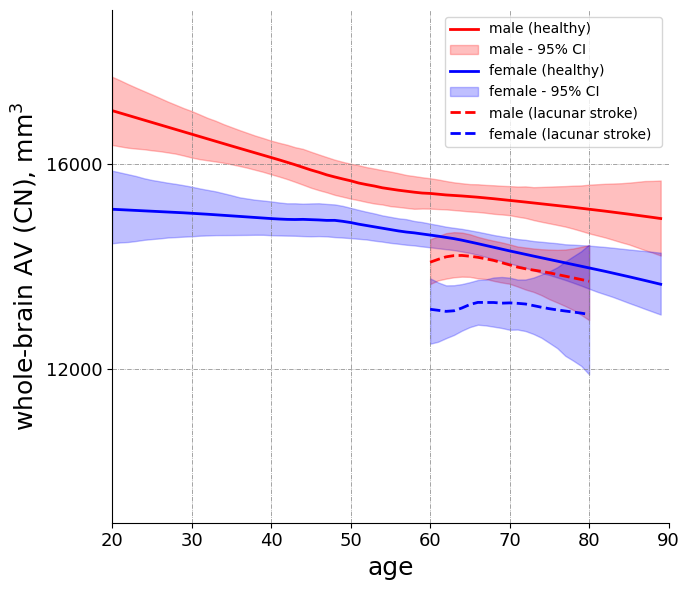

In [35]:
# Plot the the smoothed curve, and the confidence intervals
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Helvetica Neue']

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(health_age_male, y_smoothed_male_health, label='male (healthy)', color='red', linewidth=2)
ax.fill_between(health_age_male, lower_bound_male_health, upper_bound_male_health, color='red', alpha=0.25, label='male - 95% CI')
ax.plot(health_age_female, y_smoothed_female_health, label='female (healthy)', color='blue', linewidth=2)
ax.fill_between(health_age_female, lower_bound_female_health, upper_bound_female_health, color='blue', alpha=0.25, label='female - 95% CI')
ax.plot(unhealth_age_male_filtered, y_smoothed_male_unhealth, label='male (lacunar stroke)', color='red', linewidth=2, linestyle='--', )
ax.fill_between(unhealth_age_male_filtered, lower_bound_male_unhealth, upper_bound_male_unhealth, color='red', alpha=0.25)
ax.plot(unhealth_age_female_filtered, y_smoothed_female_unhealth, label='female (lacunar stroke) ', color='blue', linewidth=2, linestyle='--')
ax.fill_between(unhealth_age_female_filtered, lower_bound_female_unhealth, upper_bound_female_unhealth, color='blue', alpha=0.25)

ax.set_xlabel('age', fontsize=18)
ax.set_ylabel('whole-brain AV (CN), mm$^3$', fontsize=18)
ax.set_xlim((20,90))
ax.set_ylim((9000, 19000))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
plt.setp(ax.get_xticklabels(), fontsize=13)
plt.setp(ax.get_yticklabels(), fontsize=13)
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.savefig('./plots/CN_health_vs_lanunarstroke_whole_AV.png', dpi=500, bbox_inches='tight')
plt.show()

####  AV Curves in 4 typical regions, healthy subjects vs subjects with lanunar stroke

number of male subjects: 424
number of female subjects: 462
number of male subjects: 217
number of female subjects: 117
number of subjects after filtering: 205
number of subjects after filtering: 109
number of male subjects: 424
number of female subjects: 462
number of male subjects: 217
number of female subjects: 117
number of subjects after filtering: 204
number of subjects after filtering: 111
number of male subjects: 424
number of female subjects: 462
number of male subjects: 217
number of female subjects: 117
number of subjects after filtering: 205
number of subjects after filtering: 115
number of male subjects: 424
number of female subjects: 462
number of male subjects: 217
number of female subjects: 117
number of subjects after filtering: 206
number of subjects after filtering: 110


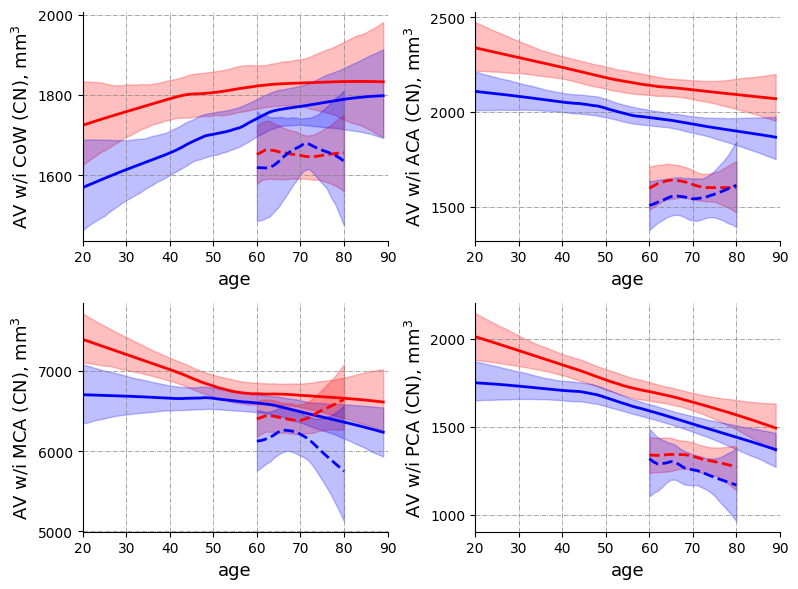

In [36]:
fig = plt.figure(figsize=(8, 6))
column_names = ['CoW', 'ACA', 'MCA', 'PCA']
for idx, column_name in enumerate(column_names):
    ax = fig.add_subplot(2, 2, idx+1)
    health_param_male, health_age_male, health_param_female, health_age_female = prepare_sample(health_param_data, column_name=column_name.upper())
    # Apply LOESS smoothing
    # Fraction of data used for smoothing
    y_smoothed_male_health, lower_bound_male_health, upper_bound_male_health = lowess_fit(health_age_male, health_param_male, frac = 0.75)
    y_smoothed_female_health, lower_bound_female_health, upper_bound_female_health = lowess_fit(health_age_female, health_param_female, frac = 0.75)
    ax.plot(health_age_male, y_smoothed_male_health, label='male (healthy)', color='red', linewidth=2)
    ax.fill_between(health_age_male, lower_bound_male_health, upper_bound_male_health, color='red', alpha=0.25, label='male - 95% CI')

    ax.plot(health_age_female, y_smoothed_female_health, label='female (healthy)', color='blue', linewidth=2)
    ax.fill_between(health_age_female, lower_bound_female_health, upper_bound_female_health, color='blue', alpha=0.25, label='female - 95% CI')



    unhealth_param_male, unhealth_age_male, unhealth_param_female, unhealth_age_female = prepare_sample(unhealth_param_data, column_name=column_name.upper())

    unhealth_param_male_filtered, unhealth_age_male_filtered = filter_samples(unhealth_param_male, unhealth_age_male, threshold=2.0)
    unhealth_param_female_filtered, unhealth_age_female_filtered = filter_samples(unhealth_param_female, unhealth_age_female, threshold=2.0)
    y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = lowess_fit(unhealth_age_male_filtered, unhealth_param_male_filtered, frac = 0.85)
    y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = lowess_fit(unhealth_age_female_filtered, unhealth_param_female_filtered, frac = 0.85)

    unhealth_age_male_filtered, y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = crop_age_range_line(unhealth_age_male_filtered, y_smoothed_male_unhealth, 
                                                                                                                                 lower_bound_male_unhealth, upper_bound_male_unhealth)
    unhealth_age_female_filtered, y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = crop_age_range_line(unhealth_age_female_filtered, y_smoothed_female_unhealth, 
                                                                                                                                 lower_bound_female_unhealth, upper_bound_female_unhealth)

    ax.plot(unhealth_age_male_filtered, y_smoothed_male_unhealth, label='male (lacunar stroke)', color='red', linewidth=2, linestyle='--', )
    ax.fill_between(unhealth_age_male_filtered, lower_bound_male_unhealth, upper_bound_male_unhealth, color='red', alpha=0.25)

    ax.plot(unhealth_age_female_filtered, y_smoothed_female_unhealth, label='female (lacunar stroke)', color='blue', linewidth=2, linestyle='--')
    ax.fill_between(unhealth_age_female_filtered, lower_bound_female_unhealth, upper_bound_female_unhealth, color='blue', alpha=0.25)
    
    ax.set_xlabel('age', fontsize=13)
    ax.set_ylabel('AV w/i ' + column_name + ' (CN), mm$^3$', fontsize=13)
    ax.axes.tick_params(labelsize=10)
    ax.set_xlim((20,90))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
    
plt.tight_layout()
plt.savefig('./plots/CN_health_vs_lacunarstroke_4R_AV.png', dpi=500, bbox_inches='tight')
plt.show()    

## AV Curves for CN healthy subjects vs CN subjects with large territorial stroke

In [37]:
# load healthy params 
health_param_file = './data/chinese_vascular_volume.csv'
health_param_data = pd.read_csv(health_param_file)
health_param_data = health_param_data.dropna()
health_param_data.head()

,av,COW,PCA,MCA,ACA,PSC1,PSC2,PSC3,PMC,SAC,...,AC1,AC2,PGC,POper,PT,DPC2,Porb,RA,age,sex
0,14696.875,2257.000,1245.875,6312.75,1833.250,0,0.000,1.000,0.000,0,...,168.000,33.500,45.500,22.000,0.125,0.000,117.375,2898.125,88,1
1,13453.500,1476.125,1204.000,5490.25,2004.625,0,34.000,0.000,0.000,0,...,108.750,128.000,23.125,74.125,14.750,0.000,67.000,2861.375,84,1
2,16491.125,2219.000,1886.375,7574.00,2219.250,0,26.000,31.125,22.125,0,...,131.625,247.125,125.750,224.375,50.500,0.000,210.125,3256.625,77,1
3,11271.875,1096.750,1373.500,5340.00,1301.875,0,7.375,6.750,17.875,0,...,76.875,134.500,16.125,181.000,18.000,0.125,53.750,2598.500,42,2
4,16967.625,2918.750,1516.000,6773.75,1888.250,0,9.625,3.250,22.375,0,...,61.625,256.000,82.000,174.125,24.750,0.000,69.250,3510.750,85,1


In [38]:
unhealth_param_file = './data/large-territorial-stroke_chinese_vascular_volume.csv'
unhealth_param_data = pd.read_csv(unhealth_param_file)
unhealth_param_data = unhealth_param_data.dropna()
unhealth_param_data

,av,COW,ACA,MCA,PCA,age,sex
0,15228.250,1777.625,2121.250,7511.875,1187.375,75,1
1,10025.875,1208.750,1055.875,5238.625,749.000,68,2
2,12342.375,1376.125,1458.625,5904.000,1110.875,71,2
3,11678.875,2049.250,1430.625,5307.000,1067.750,63,1
4,13305.500,1641.625,1467.625,5830.875,1260.000,71,2
...,...,...,...,...,...,...,...
160,15501.375,1736.125,1718.500,7234.250,1548.625,74,2
161,11948.375,1566.250,1167.125,5717.500,1014.250,71,2
162,11405.625,1195.375,1651.500,4768.375,1900.000,70,1
163,15164.875,2003.250,1646.875,7695.625,1156.375,81,1


#### whole-brain AV Curves, healthy subjects vs subjects with large territorial stroke

In [39]:
## whole-brain AV  
health_param_male, health_age_male, health_param_female, health_age_female = prepare_sample(health_param_data, column_name='av')
# Apply LOESS smoothing
frac = 0.75 # Fraction of data used for smoothing
y_smoothed_male_health, lower_bound_male_health, upper_bound_male_health = lowess_fit(health_age_male, health_param_male, frac)
y_smoothed_female_health, lower_bound_female_health, upper_bound_female_health = lowess_fit(health_age_female, health_param_female, frac)

number of male subjects: 424
number of female subjects: 462


In [40]:
unhealth_param_male, unhealth_age_male, unhealth_param_female, unhealth_age_female = prepare_sample(unhealth_param_data, column_name='av')

unhealth_param_male_filtered, unhealth_age_male_filtered = filter_samples(unhealth_param_male, unhealth_age_male, threshold=2.0)
unhealth_param_female_filtered, unhealth_age_female_filtered = filter_samples(unhealth_param_female, unhealth_age_female, threshold=2.0)

# Apply LOESS smoothing
frac = 0.85 # Fraction of data used for smoothing
y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = lowess_fit(unhealth_age_male_filtered, unhealth_param_male_filtered, frac, n_bootstrap=1000)
y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = lowess_fit(unhealth_age_female_filtered, unhealth_param_female_filtered, frac, n_bootstrap=1000)

unhealth_age_male_filtered, y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = crop_age_range_line(unhealth_age_male_filtered, y_smoothed_male_unhealth, 
                                                                                                                                 lower_bound_male_unhealth, upper_bound_male_unhealth)
unhealth_age_female_filtered, y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = crop_age_range_line(unhealth_age_female_filtered, y_smoothed_female_unhealth, 
                                                                                                                                 lower_bound_female_unhealth, upper_bound_female_unhealth)

number of male subjects: 103
number of female subjects: 62
number of subjects after filtering: 96
number of subjects after filtering: 60


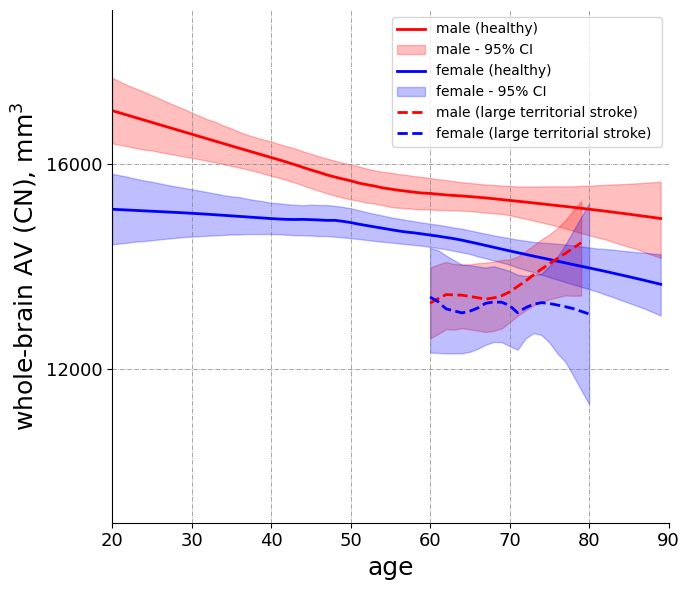

In [41]:
# Plot the the smoothed curve, and the confidence intervals
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Helvetica Neue']

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(health_age_male, y_smoothed_male_health, label='male (healthy)', color='red', linewidth=2)
ax.fill_between(health_age_male, lower_bound_male_health, upper_bound_male_health, color='red', alpha=0.25, label='male - 95% CI')
ax.plot(health_age_female, y_smoothed_female_health, label='female (healthy)', color='blue', linewidth=2)
ax.fill_between(health_age_female, lower_bound_female_health, upper_bound_female_health, color='blue', alpha=0.25, label='female - 95% CI')
ax.plot(unhealth_age_male_filtered, y_smoothed_male_unhealth, label='male (large territorial stroke)', color='red', linewidth=2, linestyle='--', )
ax.fill_between(unhealth_age_male_filtered, lower_bound_male_unhealth, upper_bound_male_unhealth, color='red', alpha=0.25)
ax.plot(unhealth_age_female_filtered, y_smoothed_female_unhealth, label='female (large territorial stroke) ', color='blue', linewidth=2, linestyle='--')
ax.fill_between(unhealth_age_female_filtered, lower_bound_female_unhealth, upper_bound_female_unhealth, color='blue', alpha=0.25)

ax.set_xlabel('age', fontsize=18)
ax.set_ylabel('whole-brain AV (CN), mm$^3$', fontsize=18)
ax.set_xlim((20,90))
ax.set_ylim((9000, 19000))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
plt.setp(ax.get_xticklabels(), fontsize=13)
plt.setp(ax.get_yticklabels(), fontsize=13)
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.savefig('./plots/CN_health_vs_largeterritorialstroke_whole_AV.png', dpi=500, bbox_inches='tight')
plt.show()

####  AV Curves in 4 typical regions, healthy subjects vs subjects with large territorial stroke

number of male subjects: 424
number of female subjects: 462
number of male subjects: 103
number of female subjects: 62
number of subjects after filtering: 99
number of subjects after filtering: 58
number of male subjects: 424
number of female subjects: 462
number of male subjects: 103
number of female subjects: 62
number of subjects after filtering: 97
number of subjects after filtering: 60
number of male subjects: 424
number of female subjects: 462
number of male subjects: 103
number of female subjects: 62
number of subjects after filtering: 96
number of subjects after filtering: 58
number of male subjects: 424
number of female subjects: 462
number of male subjects: 103
number of female subjects: 62
number of subjects after filtering: 96
number of subjects after filtering: 59


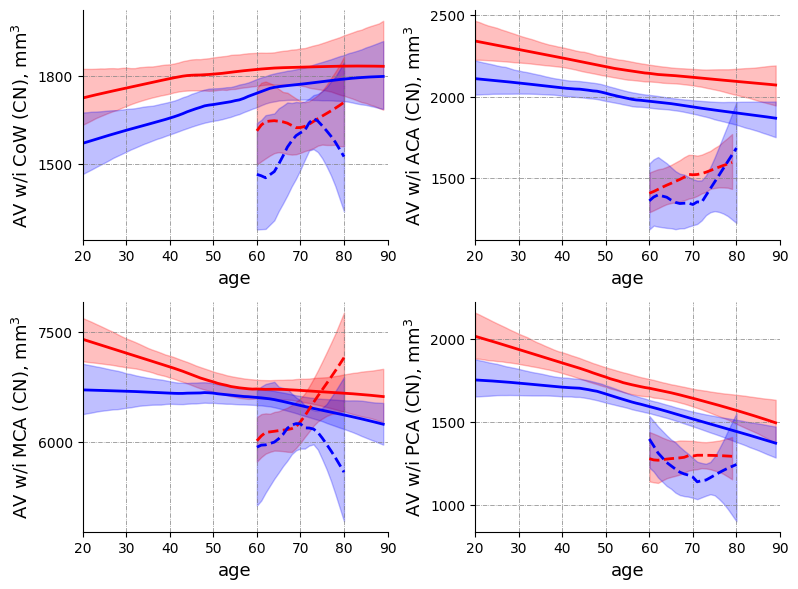

In [42]:
fig = plt.figure(figsize=(8, 6))
column_names = ['CoW', 'ACA', 'MCA', 'PCA']
for idx, column_name in enumerate(column_names):
    ax = fig.add_subplot(2, 2, idx+1)
    health_param_male, health_age_male, health_param_female, health_age_female = prepare_sample(health_param_data, column_name=column_name.upper())
    # Apply LOESS smoothing
    # Fraction of data used for smoothing
    y_smoothed_male_health, lower_bound_male_health, upper_bound_male_health = lowess_fit(health_age_male, health_param_male, frac = 0.75)
    y_smoothed_female_health, lower_bound_female_health, upper_bound_female_health = lowess_fit(health_age_female, health_param_female, frac = 0.75)
    ax.plot(health_age_male, y_smoothed_male_health, label='male (healthy)', color='red', linewidth=2)
    ax.fill_between(health_age_male, lower_bound_male_health, upper_bound_male_health, color='red', alpha=0.25, label='male - 95% CI')

    ax.plot(health_age_female, y_smoothed_female_health, label='female (healthy)', color='blue', linewidth=2)
    ax.fill_between(health_age_female, lower_bound_female_health, upper_bound_female_health, color='blue', alpha=0.25, label='female - 95% CI')



    unhealth_param_male, unhealth_age_male, unhealth_param_female, unhealth_age_female = prepare_sample(unhealth_param_data, column_name=column_name.upper())

    unhealth_param_male_filtered, unhealth_age_male_filtered = filter_samples(unhealth_param_male, unhealth_age_male, threshold=2.0)
    unhealth_param_female_filtered, unhealth_age_female_filtered = filter_samples(unhealth_param_female, unhealth_age_female, threshold=2.0)
    y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = lowess_fit(unhealth_age_male_filtered, unhealth_param_male_filtered, frac = 0.85)
    y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = lowess_fit(unhealth_age_female_filtered, unhealth_param_female_filtered, frac = 0.85)

    unhealth_age_male_filtered, y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = crop_age_range_line(unhealth_age_male_filtered, y_smoothed_male_unhealth, 
                                                                                                                                 lower_bound_male_unhealth, upper_bound_male_unhealth)
    unhealth_age_female_filtered, y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = crop_age_range_line(unhealth_age_female_filtered, y_smoothed_female_unhealth, 
                                                                                                                                 lower_bound_female_unhealth, upper_bound_female_unhealth)

    ax.plot(unhealth_age_male_filtered, y_smoothed_male_unhealth, label='male (large territorial stroke)', color='red', linewidth=2, linestyle='--', )
    ax.fill_between(unhealth_age_male_filtered, lower_bound_male_unhealth, upper_bound_male_unhealth, color='red', alpha=0.25)

    ax.plot(unhealth_age_female_filtered, y_smoothed_female_unhealth, label='female (large territorial stroke)', color='blue', linewidth=2, linestyle='--')
    ax.fill_between(unhealth_age_female_filtered, lower_bound_female_unhealth, upper_bound_female_unhealth, color='blue', alpha=0.25)
    
    ax.set_xlabel('age', fontsize=13)
    ax.set_ylabel('AV w/i ' + column_name + ' (CN), mm$^3$', fontsize=13)
    ax.axes.tick_params(labelsize=10)
    ax.set_xlim((20,90))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
    
plt.tight_layout()
plt.savefig('./plots/CN_health_vs_largeterritorialstroke_4R_AV.png', dpi=500, bbox_inches='tight')
plt.show()    